In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import timm


# Dataloaders with standard PyTorch Dataset

In [ ]:
test_on = 'gpu'

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import os
from PIL import Image

from lit_ecology_classifier.data.image_transformation import define_transformation_pipeline

transformations = define_transformation_pipeline(train=True)



# Use the default ImageFolder to get every iamge
data_dir = "../data/mini_dataset" 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transformations)

# Print some information about the dataset
print("Classes:", full_dataset.classes)
print("Class:", full_dataset.class_to_idx)
print("Gesamtzahl der Bilder:", len(full_dataset))


# Minidataset to check if it learns
#full_dataset = torch.utils.data.Subset(full_dataset, range(1200))  

# Split the dataset into training, validation and test set
train_size = int(0.7 * len(full_dataset))  # 70% für Training
val_size = int(0.15 * len(full_dataset))   # 15% für Validierung
test_size = len(full_dataset) - train_size - val_size  # 15% für Test

print("Trainingsgröße:", train_size)
print("Validierungsgröße:", val_size)
print("Testgröße:", test_size)

# Random split
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size, test_size])



Classes: ['aphanizomenon', 'dinobryon', 'keratella_quadrata', 'polyarthra', 'uroglena']
Class: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'uroglena': 4}
Gesamtzahl der Bilder: 6944
Trainingsgröße: 4860
Validierungsgröße: 1041
Testgröße: 1043


In [ ]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=5)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=5)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Example of a batch images

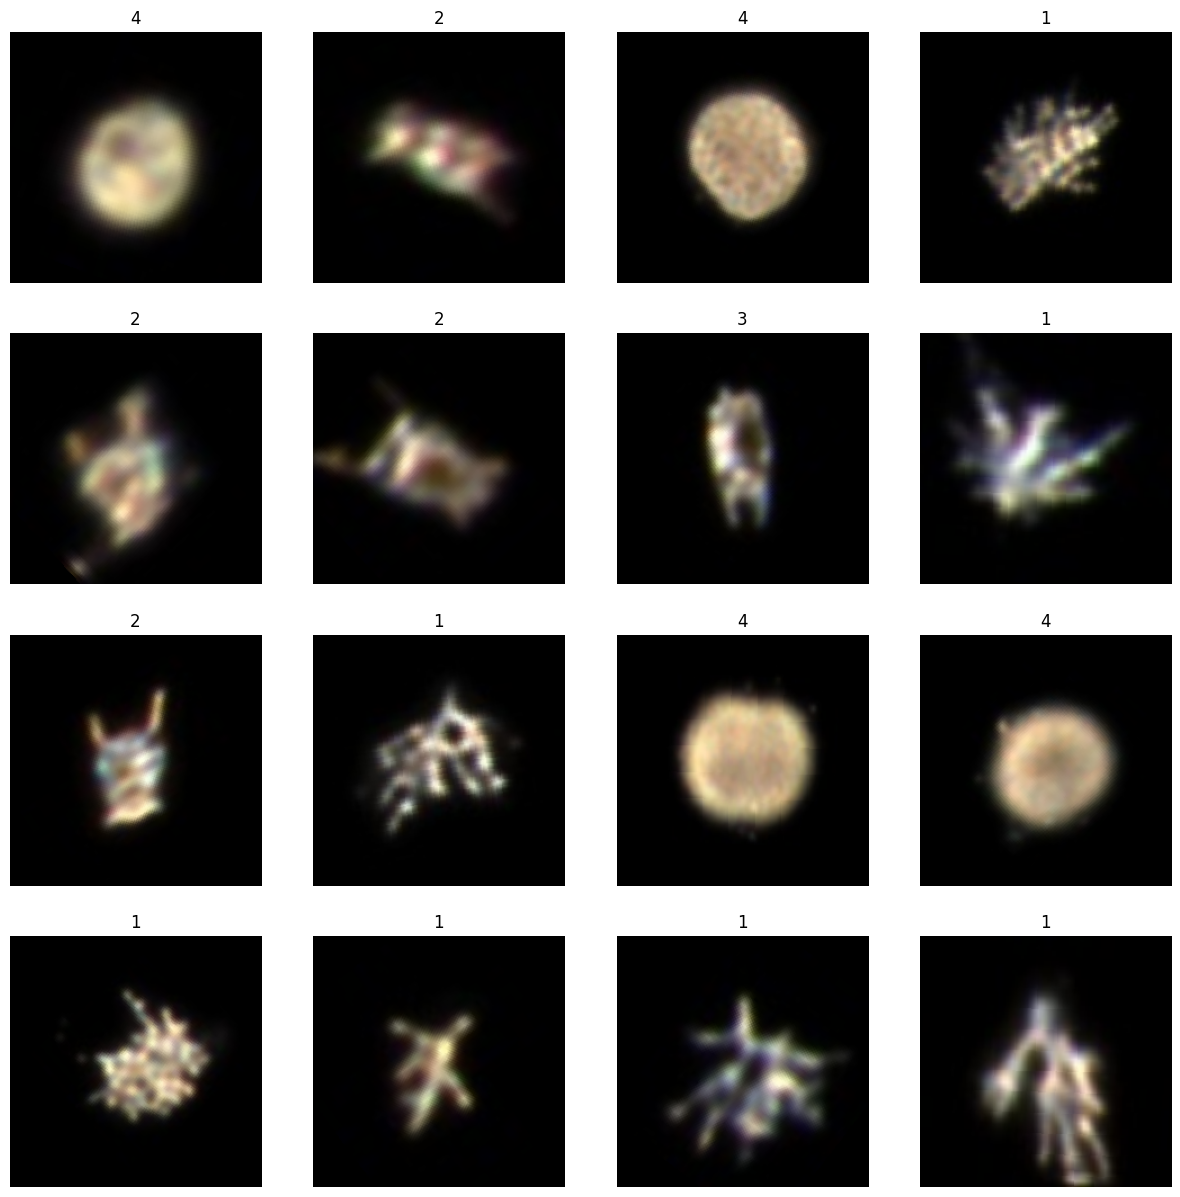

In [ ]:
single_batch = next(iter(train_loader))
image, label = single_batch


import matplotlib.pyplot as plt
import numpy as np

def plot_images(images, labels):
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.axis('off')
        ax.set_title(labels[i].item())
    plt.show()

plot_images(image, label)

# Create a simple model

In [ ]:
len_classes = len(full_dataset.classes)
print(len_classes)

5


## Load from timm

In [ ]:
def get_model(num_classes=2):
    # Load MobileNetV3 Large from timm
    model = timm.create_model(
        'mobilenetv3_large_100.miil_in21k_ft_in1k',
        pretrained=True,
        num_classes=num_classes  # 2 classes: 0 and 1
    )

    # Freeze all layers except the last one
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    # move model to device

    return model
model =  get_model(len_classes)

## Simple model with logs 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import lightning as pl
from torchmetrics import Accuracy
import torch.nn.functional as F
from lightning.pytorch.loggers import CSVLogger
from lightning import Trainer

csv_logger = CSVLogger("logs", name="my_experiment")


from lit_ecology_classifier.helpers.modelling_plots import plot_loss_acc


class MinimalisticalisticModel(pl.LightningModule):
    def __init__(self, model, lr=0.001):
        super(MinimalisticalisticModel, self).__init__()
        self.model = model
        self.lr = lr
        self.criterion = nn.CrossEntropyLoss()
        self.train_acc = Accuracy(task="multiclass", num_classes=len_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=len_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self.model(inputs)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        acc = self.train_acc(preds, labels)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self.model(inputs)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1) 
        acc = self.val_acc(preds, labels)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def on_validation_end(self):
        return super().on_validation_end()

    def configure_optimizers(self):
        return optim.Adam(self.model.parameters(), lr=self.lr)
    
    def on_fit_end(self) -> None:
        """
        If the model is not using wandb, plot the loss and accuracy curves at the end of training
        and save them in the output folder.
        """
        print(self.logger.log_dir)
        
        plot_loss_acc(self.trainer.logger)
        plt.show(plot_loss_acc)
        return super().on_fit_end()

## Init minimalistic model and trainer

In [ ]:
from lightning.pytorch.callbacks  import ModelCheckpoint,LearningRateMonitor, EarlyStopping

mini_Model = MinimalisticalisticModel(model)

checkpoint_callback = [ModelCheckpoint(
    monitor="val_loss",        # Welche Metrik beobachtet werden soll
    dirpath="checkpoints",     # Wohin gespeichert werden soll
    filename="model-{epoch:02d}-{val_loss:.2f}",  # Namensformat
    save_top_k=3,              # Wie viele beste Modelle behalten werden sollen
    mode="min",                # "min" für Verlust, "max" für Genauigkeit
), LearningRateMonitor(logging_interval="step"),EarlyStopping(monitor="val_loss", patience=3)]

trainer = pl.Trainer(
        max_epochs=5,
        # strategy for notebooks
        devices=1,
        callbacks=checkpoint_callback,
        strategy= "auto" if test_on == "cpu" else "ddp_notebook" ,
        accelerator= "cpu" if test_on == "cpu" else "gpu",
        log_every_n_steps=10,
        logger=csv_logger
    )


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


## Train the minimalistic model

In [ ]:
trainer.fit(mini_Model,train_dataloaders= train_loader, val_dataloaders= val_loader)


/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/checkpoints exists and is not empty.

  | Name      | Type               | Params
-------------------------------------------------
0 | model     | MobileNetV3        | 4.2 M 
1 | criterion | CrossEntropyLoss   | 0     
2 | train_acc | MulticlassAccuracy | 0     
3 | val_acc   | MulticlassAccuracy | 0     
-------------------------------------------------
6.4 K     Trainable params
4.2 M     Non-trainable params
4.2 M     Total params
16.834    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


# Test if the Lit_eco model is working

## Init the model

In [ ]:

from lit_ecology_classifier.models.model import LitClassifier

train_out =  "./train_out"

model_eco = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=".",  # "Main directory where the training parameters are stored"
    class_map = full_dataset.class_to_idx,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3s', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    add_layer=False,             # Add additional layers to the model
    finetune=False,              # if True, only train the head of the network
    batch_size=batch_size,       # Batch size for training
    lr=0.001,                     # Learning rate for training
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
    testing=False,               # Set this to True if in testing mode, False for training
    no_TTA=False                 # Test-time augmentation - only for predict stage, 
)

model_eco.hparams.TTA = False


Model setup completed.
Model architecture:  mobilenetv3s
Number of classes:  5
Pretrained:  True
Total number of trainable parameters: %d 1021997
Total number of parameters: %d 1021997
Using standard cross entropy loss


## Init a new trainer

In [ ]:
test_on = 'gpu'
trainer2 = pl.Trainer(
        max_epochs=10,
        # strategy for notebooks
        devices=1,
        callbacks=checkpoint_callback,
        strategy= "auto" if test_on == "cpu" else "ddp_notebook" ,
        accelerator= "cpu" if test_on == "cpu" else "gpu",
        log_every_n_steps=10,
        logger=csv_logger
    )

Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [ ]:
trainer2.fit(model =model_eco , train_dataloaders= train_loader, val_dataloaders= val_loader)

del model_eco, trainer2

NameError: name 'model_eco' is not defined

## Check with the dataloader

In [ ]:
# load split from winterschool
from lit_ecology_classifier.splitting.split_processor import SplitProcessor
from pathlib import Path
artifacts_path = Path('..') / "data"  / "mini_dataset_artifact"
overview_path = artifacts_path / "overview.csv"

random_split_processor = SplitProcessor(
                                artefacts_folder= artifacts_path,
                                split_hash= "4d1860aa6bfc3ab6f32cb7a4bdc8cc9b0092213b3b0c9c0fb11eebe304cf69d5"
                                )

df = random_split_processor.get_split_df()
df.head()

,image,class,sha256,date,version_mini,image_path,class_map,split
0,SPC-EAWAG-0P5X-1657469153953175-61976020245260...,keratella_quadrata,2bf0ee058f81569527f44b2902f99eebfff315ef04b66f...,2022-07-10 16:05:53+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,test
1,SPC-EAWAG-0P5X-1529971633256303-1685616084007-...,keratella_quadrata,b51329bb043ea0cbf4e645dbd8b3e2b671212894b0a979...,2018-06-26 00:07:13+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train
2,SPC-EAWAG-0P5X-1534593947131228-276543382109-0...,keratella_quadrata,370040c99ac335db709635be9d49dc2d9e95b314fab6d4...,2018-08-18 12:05:47+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train
3,SPC-EAWAG-0P5X-1530061231883348-1775213498675-...,keratella_quadrata,358e800d0f731d9bade3bc958cbb04822b2a97af9b7a69...,2018-06-27 01:00:31+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,test
4,SPC-EAWAG-0P5X-1657375349510541-61882217063707...,keratella_quadrata,9b925a9ab1aa0e77493fb77ac73c35fe1358fbaab5ceef...,2022-07-09 14:02:29+00:00,True,../data/mini_dataset/keratella_quadrata/SPC-EA...,2,train


In [ ]:
from lit_ecology_classifier.data.datamodule import DataModule
import logging
from lightning.pytorch.loggers import CSVLogger

batch_size=32
max_epochs = 10
dataset_path = Path("..") / "data" / "mini_dataset"
datamodule = DataModule(
        datapath= dataset_path,
        dataset = "mini_example",
        batch_size= batch_size,
        splits= df,
        augmentation_level = "low",
        resize_with_proportions = True,
        target_size = 224,
)

datamodule.setup()


Train size of df:  5555
Validation size of df:  694
Test size of df:  695


In [ ]:
random_split_processor.get_class_map()

{'keratella_quadrata': 2,
 'uroglena': 4,
 'dinobryon': 1,
 'polyarthra': 3,
 'aphanizomenon': 0}

In [ ]:
full_dataset.class_to_idx

{'aphanizomenon': 0,
 'dinobryon': 1,
 'keratella_quadrata': 2,
 'polyarthra': 3,
 'uroglena': 4}

In [ ]:
from lit_ecology_classifier.models.model import LitClassifier

train_out =  "./train_out"

model_eco_datamodul = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=".",  # "Main directory where the training parameters are stored"
    class_map = full_dataset.class_to_idx,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3s', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    add_layer=False,             # Add additional layers to the model
    finetune=False,              # if True, only train the head of the network
    batch_size=batch_size,       # Batch size for training
    lr=1e-6,                     # Learning rate for training
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
    testing=False,               # Set this to True if in testing mode, False for training
    no_TTA=False                 # Test-time augmentation - only for predict stage, 
)
model_eco_datamodul.hparams.TTA = False
trainer3 = pl.Trainer(
        max_epochs=10,
        # strategy for notebooks
        devices=1,
        callbacks=checkpoint_callback,
        strategy= "ddp_notebook" if test_on == "gpu" else "auto" ,
      
        log_every_n_steps=10,
        logger=csv_logger
    )

Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Model setup completed.
Model architecture:  mobilenetv3s
Number of classes:  5
Pretrained:  True
Total number of trainable parameters: %d 1021997
Total number of parameters: %d 1021997
Using standard cross entropy loss


Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------



Train size of df:  5555
Validation size of df:  694
Test size of df:  695


/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type             | Params
-------------------------------------------
0 | model | MobileNetV3      | 1.0 M 
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.088     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:127: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:121: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[i].set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

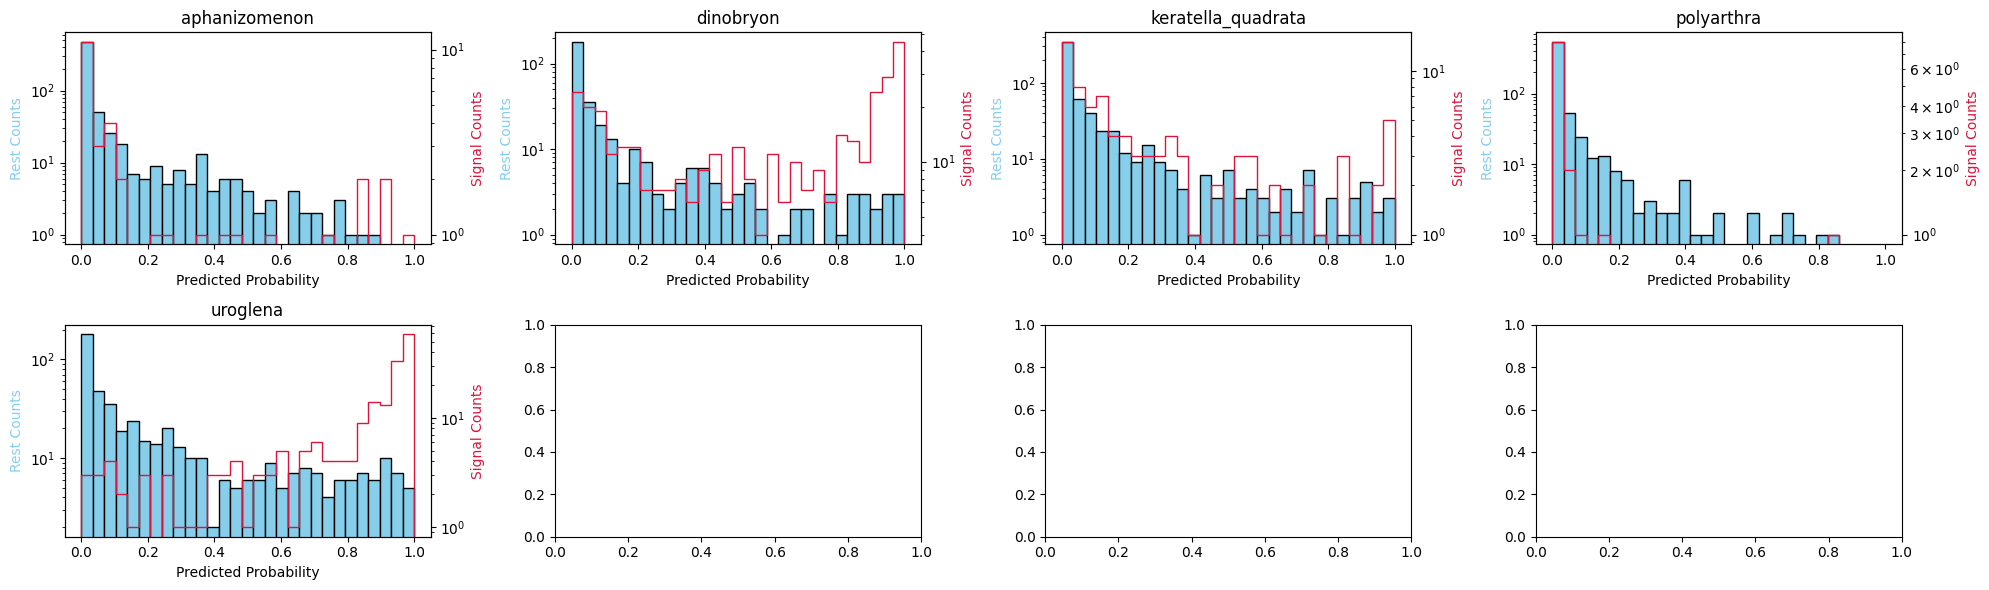

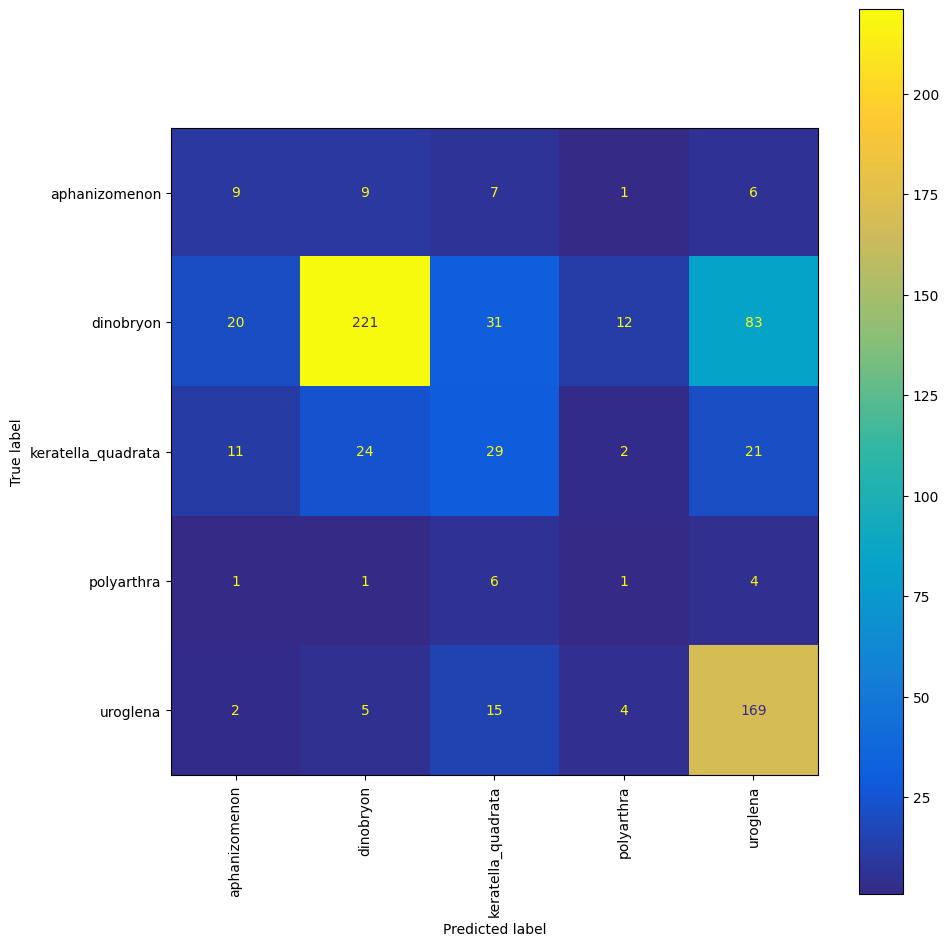

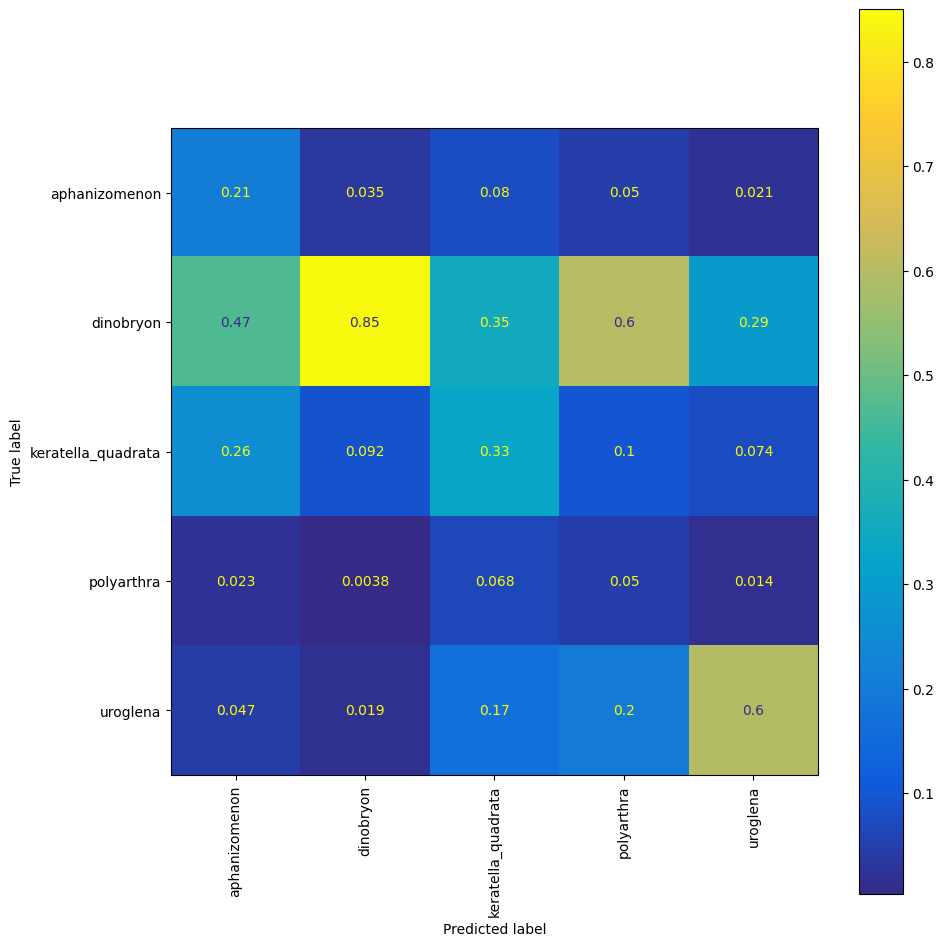

`Trainer.fit` stopped: `max_epochs=10` reached.


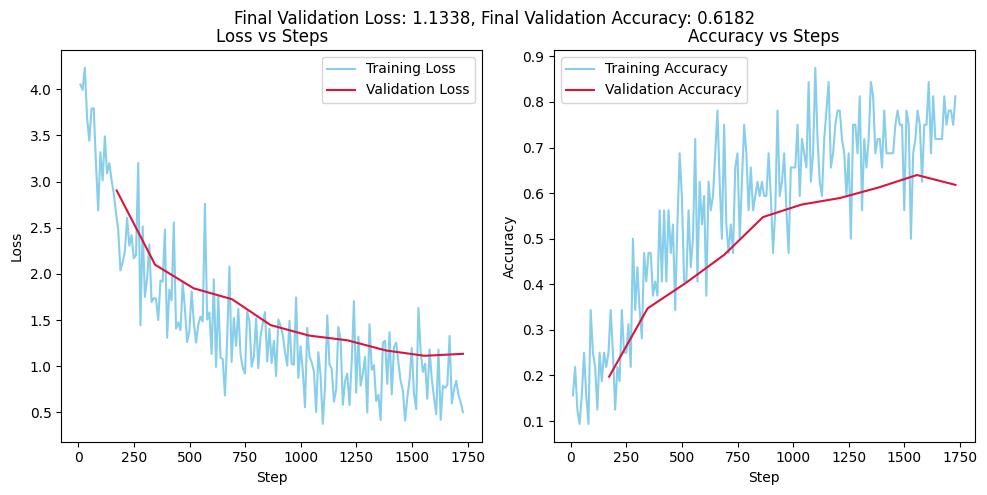

Artefatcs saved to logs/my_experiment/version_57


/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [ ]:
trainer3.fit(model = model_eco_datamodul , datamodule= datamodule)
del model_eco_datamodul, trainer3

# Try if another dataloader works better

In [ ]:
# create a custom datset that takes a tuple of image path and label

class CustomDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data[idx][0]
        image = Image.open(img_name)
        label = self.data[idx][1]

        if self.transform:
            image = self.transform(image)

        return image, label
    


In [ ]:
df["split"].unique()

array(['test', 'train', 'val'], dtype=object)

In [ ]:
# create a list of tuples with image path and label from the df
train_list = df[df["split"] == "train"][["image_path", "class_map"]].values.tolist()
val_list = df[df["split"] == "val"][["image_path", "class_map"]].values.tolist()
test_list = df[df["split"] == "test"][["image_path", "class_map"]].values.tolist()


In [ ]:
val_list_loader = CustomDataset(val_list, transformations)
train_list_loader = CustomDataset(train_list, transformations)
test_list_loader = CustomDataset(test_list, transformations)


batch_size = 32
train_loader_l = DataLoader(train_list_loader, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader_l = DataLoader(val_list_loader, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader_l = DataLoader(test_list_loader, batch_size=batch_size, shuffle=False, num_workers=4)



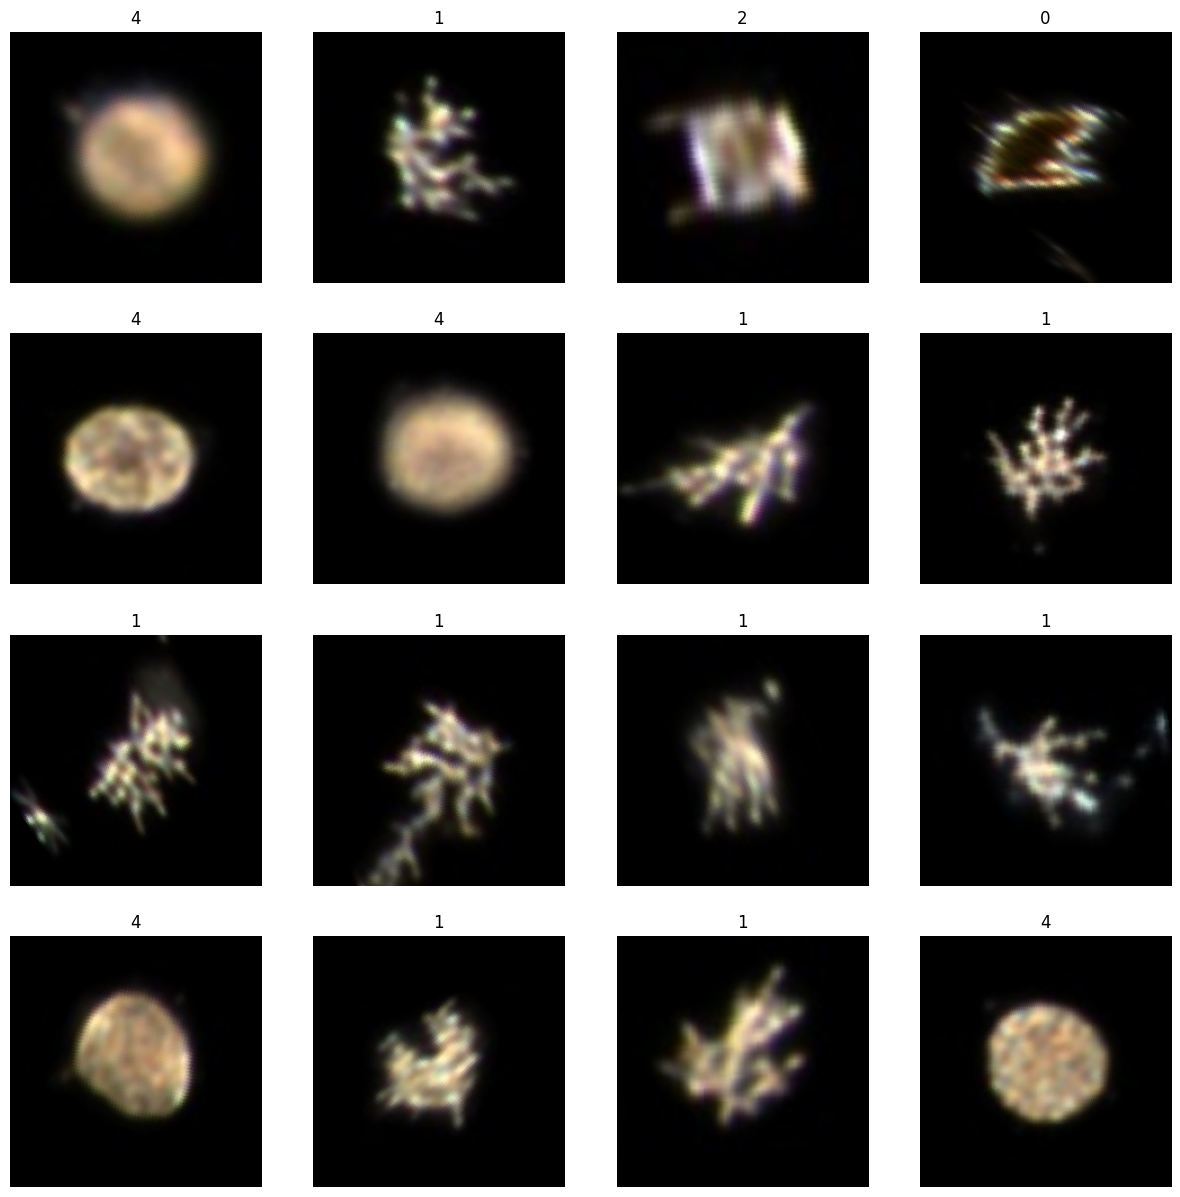

In [ ]:
single_batch = next(iter(train_loader_l))
image, label = single_batch


import matplotlib.pyplot as plt
import numpy as np

def plot_images(images, labels):
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.axis('off')
        ax.set_title(labels[i].item())
    plt.show()

plot_images(image, label)

In [ ]:

train_out =  "./train_out"

model_eco_new_loader = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=".",  # "Main directory where the training parameters are stored"
    class_map = full_dataset.class_to_idx,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3s', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    add_layer=False,             # Add additional layers to the model
    finetune=False,              # if True, only train the head of the network
    batch_size=batch_size,       # Batch size for training
    lr=0.001,                     # Learning rate for training
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
    testing=False,               # Set this to True if in testing mode, False for training
    no_TTA=False                 # Test-time augmentation - only for predict stage, 
)

model_eco_new_loader.hparams.TTA = False

trainer5 = pl.Trainer(
        max_epochs=10,
        # strategy for notebooks
        devices=1,
        callbacks=checkpoint_callback,
        strategy= "ddp_notebook" if test_on == "gpu" else "auto" ,
      
        log_every_n_steps=10,
        logger=csv_logger
    )





Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Model setup completed.
Model architecture:  mobilenetv3s
Number of classes:  5
Pretrained:  True
Total number of trainable parameters: %d 1021997
Total number of parameters: %d 1021997
Using standard cross entropy loss


Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type             | Params
-------------------------------------------
0 | model | MobileNetV3      | 1.0 M 
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.088     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:127: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:121: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[i].set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

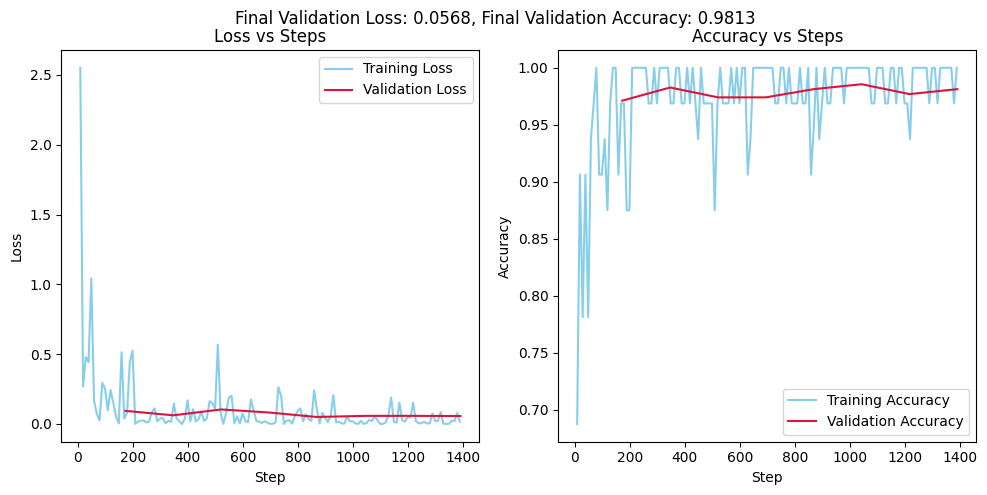

Artefatcs saved to logs/my_experiment/version_58


/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [ ]:
trainer5.fit(model =model_eco_new_loader, train_dataloaders= train_loader_l, val_dataloaders= val_loader_l)
del model_eco_new_loader, trainer5

In [ ]:
model_eco_100 = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=".",  # "Main directory where the training parameters are stored"
    class_map = full_dataset.class_to_idx,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3s', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    add_layer=False,             # Add additional layers to the model
    finetune=False,              # if True, only train the head of the network
    batch_size=batch_size,       # Batch size for training
    lr=1e-4,                     # Learning rate for training
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
    testing=False,               # Set this to True if in testing mode, False for training
    no_TTA=False                 # Test-time augmentation - only for predict stage, 
)

model_eco_100.hparams.TTA = False

trainer5 = pl.Trainer(

        max_epochs=100,
        # strategy for notebooks
        devices=1,
        callbacks=checkpoint_callback,
        strategy= "ddp_notebook" if test_on == "gpu" else "auto" ,
      
        log_every_n_steps=10,
        logger=csv_logger
    )


trainer5.fit(model =model_eco_100 , train_dataloaders= train_loader_l, val_dataloaders= val_loader_l)

Trainer already configured with model summary callbacks: [<class 'lightning.pytorch.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Model setup completed.
Model architecture:  mobilenetv3s
Number of classes:  5
Pretrained:  True
Total number of trainable parameters: %d 1021997
Total number of parameters: %d 1021997
Using standard cross entropy loss


Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/1
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 1 processes
----------------------------------------------------------------------------------------------------

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type             | Params
-------------------------------------------
0 | model | MobileNetV3      | 1.0 M 
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.088     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:127: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:121: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[i].set_yscale("log")
/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2480: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Training: |          | 0/? [00:00<?, ?it/s]

/home/EAWAG/ruizjuan/Repos/plankton_classifier/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...
